In [1]:
import pandas as pd

titanic_data = pd.read_csv('titanic.csv')
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## Exercise 1 — Duplicate Detection and Removal

In [2]:
print("Rows before:", len(titanic_data))
print("Duplicate rows found:", titanic_data.duplicated().sum())

titanic_data = titanic_data.drop_duplicates()

print("Rows after:", len(titanic_data))

Rows before: 891
Duplicate rows found: 0
Rows after: 891


No duplicate rows were found in this dataset (891 rows before and after). This confirms the Titanic training set is already clean on this front.


## Exercise 2 — Handling Missing Values


In [5]:
titanic_data.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [ ]:
# Age: impute with median (moderate amount missing, numeric, potentially skewed)
titanic_data['Age'] = titanic_data['Age'].fillna(titanic_data['Age'].median())

# Cabin: drop the column (87%+ missing, too sparse to usefully impute)
titanic_data = titanic_data.drop('Cabin', axis=1)

# Embarked: fill with the mode (only 2 missing, categorical)
titanic_data['Embarked'] = titanic_data['Embarked'].fillna(titanic_data['Embarked'].mode()[0])

# Verify no missing values remain
titanic_data.isnull().sum()

**Strategy used per column:**
- `Age` (177 missing) — filled with the median. Age is numeric and can be skewed by a few very young or old passengers, so the median is more robust than the mean.
- `Cabin` (687 missing, ~77% of the column) — dropped entirely. Too sparse to impute meaningfully; keeping it would mean guessing for most rows.
- `Embarked` (2 missing) — filled with the mode (most common port). Only 2 rows affected, so this has negligible impact either way.

## Exercise 3 — Feature Engineering

In [8]:
titanic_data['FamilySize'] = titanic_data['SibSp'] + titanic_data['Parch'] + 1
titanic_data[['SibSp', 'Parch', 'FamilySize']].head()

,SibSp,Parch,FamilySize
0,1,0,2
1,1,0,2
2,0,0,1
3,1,0,2
4,0,0,1


In [9]:
titanic_data['Title'] = titanic_data['Name'].str.extract(r',\s*([^\.]+)\.')
titanic_data[['Name', 'Title']].head()

,Name,Title
0,"Braund, Mr. Owen Harris",Mr
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs
2,"Heikkinen, Miss. Laina",Miss
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs
4,"Allen, Mr. William Henry",Mr


In [10]:
titanic_data['Title'].value_counts()

Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

In [11]:
common_titles = ['Mr', 'Miss', 'Mrs', 'Master']
titanic_data['Title'] = titanic_data['Title'].apply(lambda t: t if t in common_titles else 'Rare')

titanic_data['Title'].value_counts()

Title
Mr        517
Miss      182
Mrs       125
Master     40
Rare       27
Name: count, dtype: int64

In [12]:
titanic_data = pd.get_dummies(titanic_data, columns=['Title'], prefix='Title')
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilySize,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,2,False,False,True,False,False
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,2,False,False,False,True,False
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,1,False,True,False,False,False
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,2,False,False,False,True,False
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,1,False,False,True,False,False


In [13]:
titanic_data['Title_Rare'].sum()


np.int64(27)

Grouped 13 rare titles (each with ≤7 occurrences) into a single "Rare" category (27 total) before one-hot encoding, to avoid creating many near-empty columns. Verified with `.sum()` — 27 matches the manual count of grouped titles.

## Exercise 4 — Outlier Detection and Handling

Matplotlib is building the font cache; this may take a moment.


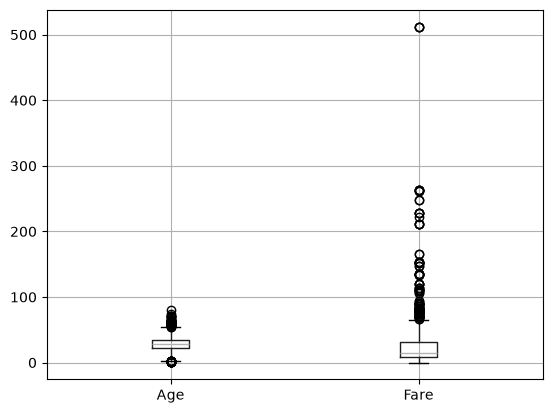

In [16]:
import matplotlib.pyplot as plt

titanic_data.boxplot(column=['Age', 'Fare'])
plt.show()

In [15]:
pip install matplotlib


   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   ----------- ---------------------------- 2.6/9.5 MB 15.5 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.5 MB 31.6 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.5 MB 31.6 MB/s eta 0:00:01
   ------------------------------------- -- 8.9/9.5 MB 13.8 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 10.5 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 10.5 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 7.2 MB/s  0:00:01
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ----------------------------------- ---- 2.1/2.3 MB 133.7 MB/s eta 0:00:01
   ---------------------------------------- 2.3/2.3 MB 7.0 MB/s  0:00:00
   ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
   ---------------------------------------  7.1/7.2 MB 228.0 MB/s eta 0:00:01
   --------------------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [17]:
Q1 = titanic_data['Fare'].quantile(0.25)
Q3 = titanic_data['Fare'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Bounds: {lower_bound} to {upper_bound}")

fare_outliers = titanic_data[(titanic_data['Fare'] < lower_bound) | (titanic_data['Fare'] > upper_bound)]
print(f"Number of Fare outliers: {len(fare_outliers)}")

Q1: 7.9104, Q3: 31.0, IQR: 23.0896
Bounds: -26.724 to 65.6344
Number of Fare outliers: 116


IQR flags 116 Fare outliers (~13% of passengers) — a large share, which reflects Fare's skewed distribution (most passengers paid a little, a few paid a lot for first-class tickets) rather than a flaw in the method itself.

In [18]:
cap_value = titanic_data['Fare'].quantile(0.98)
print(f"98th percentile cap: {cap_value}")

titanic_data['Fare_capped'] = titanic_data['Fare'].clip(upper=cap_value)

print("Before capping - max Fare:", titanic_data['Fare'].max())
print("After capping - max Fare:", titanic_data['Fare_capped'].max())

98th percentile cap: 211.3375
Before capping - max Fare: 512.3292
After capping - max Fare: 211.3375


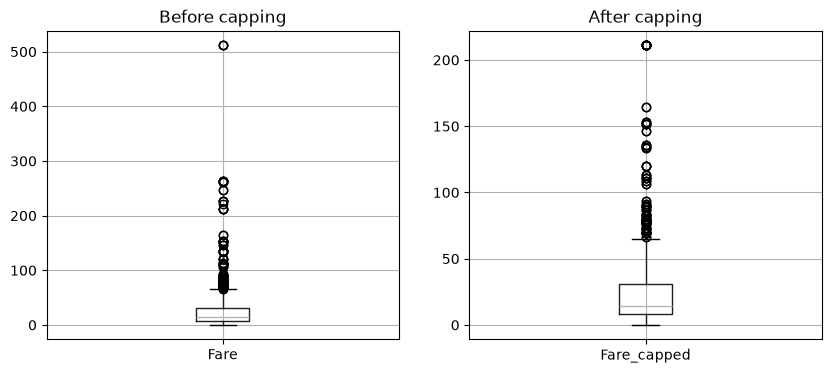

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
titanic_data.boxplot(column='Fare', ax=axes[0])
axes[0].set_title('Before capping')
titanic_data.boxplot(column='Fare_capped', ax=axes[1])
axes[1].set_title('After capping')
plt.show()

Capped Fare at the 98th percentile (£211.34) instead of removing outliers, to avoid losing ~13% of the dataset. The before/after boxplots show the extreme high value (£512) pulled down, with the rest of the distribution shape preserved.

## Exercise 5 — Data Standardization and Normalization

In [22]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# StandardScaler for Age (roughly normal/bell-shaped distribution)
scaler_standard = StandardScaler()
titanic_data['Age_scaled'] = scaler_standard.fit_transform(titanic_data[['Age']])

# MinMaxScaler for Fare_capped (skewed, now bounded after capping)
scaler_minmax = MinMaxScaler()
titanic_data['Fare_scaled'] = scaler_minmax.fit_transform(titanic_data[['Fare_capped']])

titanic_data[['Age', 'Age_scaled', 'Fare_capped', 'Fare_scaled']].head()

,Age,Age_scaled,Fare_capped,Fare_scaled
0,22.0,-0.565736,7.2500,0.034305
1,38.0,0.663861,71.2833,0.337296
2,26.0,-0.258337,7.9250,0.037499
3,35.0,0.433312,53.1000,0.251257
4,35.0,0.433312,8.0500,0.038091


In [ ]:
pip install scikit-learn


## Exercise 6 — Feature Encoding

In [23]:
titanic_data.select_dtypes(include='object').columns

C:\Users\Frenki\AppData\Local\Temp\ipykernel_16912\4178432429.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  titanic_data.select_dtypes(include='object').columns


Index(['Name', 'Sex', 'Ticket', 'Embarked'], dtype='str')

In [24]:
titanic_data = pd.get_dummies(titanic_data, columns=['Sex', 'Embarked'], prefix=['Sex', 'Embarked'])
titanic_data.filter(like='Sex_').head()

,Sex_female,Sex_male
0,False,True
1,True,False
2,True,False
3,True,False
4,False,True


One-hot encoded `Sex` and `Embarked`. Left `Name` and `Ticket` as-is — both are near-unique identifiers, not real categories to encode.

## Exercise 7 — Data Transformation for Age Feature

In [25]:
bins = [0, 12, 18, 60, 100]
labels = ['Child', 'Teen', 'Adult', 'Senior']
titanic_data['AgeGroup'] = pd.cut(titanic_data['Age'], bins=bins, labels=labels)

titanic_data['AgeGroup'].value_counts()

AgeGroup
Adult     730
Teen       70
Child      69
Senior     22
Name: count, dtype: int64

In [26]:
titanic_data = pd.get_dummies(titanic_data, columns=['AgeGroup'], prefix='AgeGroup')
titanic_data.filter(like='AgeGroup_').head()


,AgeGroup_Child,AgeGroup_Teen,AgeGroup_Adult,AgeGroup_Senior
0,False,False,True,False
1,False,False,True,False
2,False,False,True,False
3,False,False,True,False
4,False,False,True,False
